In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import r2_score


KNN (K-Nearest Neighbors) es un algoritmo de aprendizaje supervisado usado para clasificación y regresión. Su principio es simple: predice un valor o categoría basado en los K vecinos más cercanos en el espacio de características.


1- Se elige un número  K de vecinos (hiperparámetro).

2- Para una nueva observación, se calculan las distancias con todos los datos de entrenamiento.

3- Se seleccionan los  K vecinos más cercanos. 

4- Se predice el promedio de los valores de los K vecinos.


## Para determinar los vecinos más cercanos

### Definición General
La distancia euclidiana entre dos puntos \( A \) y \( B \) en un espacio \( n \)-dimensional se define como:

$$
d(A, B) = \sqrt{\sum_{i=1}^{n} (x_i^A - x_i^B)^2}
$$

#### Casos Específicos

### Caso en Dos Dimensiones
En un espacio bidimensional (\( n = 2 \)):

$$
d(A, B) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}
$$

### Caso en Tres Dimensiones
En un espacio tridimensional (\( n = 3 \)):

$$
d(A, B) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2 + (z_2 - z_1)^2}
$$

**Ejemplo Numérico:**
Si tenemos los puntos \( A(1,2,3) \) y \( B(4,6,8) \), la distancia euclidiana es:

$$
d(A, B) = \sqrt{(4 - 1)^2 + (6 - 2)^2 + (8 - 3)^2} = \sqrt{9 + 16 + 25} = \sqrt{50} \approx 7.07
$$



### Ejemplo distancia Euclidiana 2D

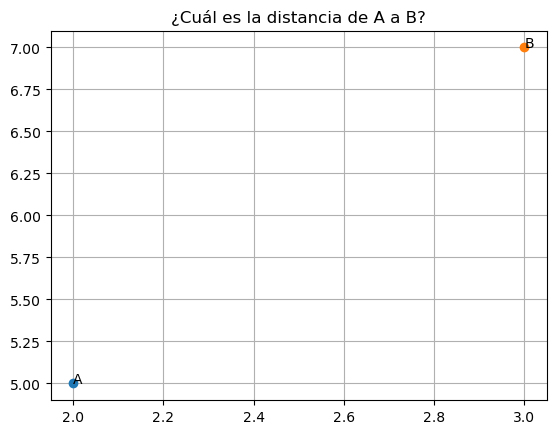

In [26]:
a = [2, 5]
b = [3, 7]

plt.title("¿Cuál es la distancia de A a B?")
plt.plot(a[0], a[1], marker="o")
plt.plot(b[0], b[1], marker="o")
plt.text(a[0], a[1], "A")
plt.text(b[0], b[1], "B")
plt.grid()

In [27]:
np.sqrt((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2)# No es interpretable 

np.float64(2.23606797749979)

## Ejemplo 3D

In [28]:
A = [2, 3, 1]
B = [5, 7, 4]

Text(0.5, 0, 'Z')

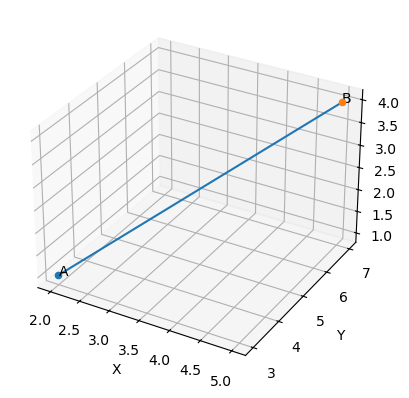

In [29]:
fig = plt.figure()

ax = fig.add_subplot(111, projection="3d")

# Puntos

ax.scatter(A[0], A[1], A[2])

ax.scatter(B[0], B[1], B[2])

# Línea entre A y B

ax.plot(
    [A[0], B[0]],
    [A[1], B[1]],
    [A[2], B[2]]

)
# Etiquetas
ax.text(A[0], A[1], A[2], "A")
ax.text(B[0], B[1], B[2], "B")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

In [30]:
# ¿Cuál es la distania euclidiana
np.sqrt((A[0] - B[0]) ** 2 + (A[1] - B[1]) ** 2 + (A[2] - B[2]) ** 2)


np.float64(5.830951894845301)

# Aplicación 

In [31]:
df = pd.read_csv('../Data/housing.csv')
df = pd.get_dummies(df)
df['total_bedrooms'] = df['total_bedrooms'].fillna(df.total_bedrooms.mean())

### Crea el modelo KNN y realiza cross validation manual

In [32]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
#hay que normalizar el knn porque es sensible a las escalas de los datos,
#  si no se normalizan los datos, 
# el modelo puede dar más importancia a las características con mayor rango de valores,
#  lo que puede afectar negativamente el rendimiento del modelo.

# Normalizar las características (KNN es sensible a escalas)
X_train_scaled = StandardScaler().fit_transform(X_train)
X_test_scaled = StandardScaler().fit_transform(X_test)

In [33]:
nn=np.arange(1, 50,1)

In [41]:
r2_results = []
for i in nn:
    model=KNeighborsRegressor(n_neighbors=i)
    model.fit(X_train_scaled, y_train)
    predicciones_current=model.predict(X_test_scaled)
    r2_current=r2_score(y_pred=predicciones_current, y_true=y_test)
    r2_results.append(r2_current)
    


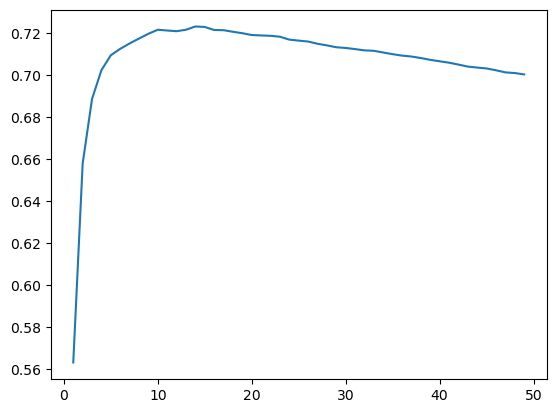

In [43]:
## Grafica los resultados
plt.plot(nn, r2_results)
